# Modélisation Forward-Looking LGD — IFRS 9 / Bâle III
## Contexte : Région SADC

Ce notebook implémente une démarche complète de modélisation statistique de la **Loss Given Default (LGD)** selon une approche *forward-looking* conforme à IFRS 9.  
La variable cible `LGD` est bornée dans `[0, 1]` — elle représente la proportion de l'exposition perdue lors d'un défaut.

**Méthodes utilisées** : Tobit, Régression Bêta, Fractional Response Model (FRM), Random Forest, XGBoost + SHAP  
**Scénarios Forward-Looking** : Baseline / Adverse / Severely Adverse calibrés sur données réelles World Bank SADC

---
## Section 0 — Setup & Imports

In [1]:
# ── Core ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import requests
import warnings
warnings.filterwarnings('ignore')

# ── Scipy ───────────────────────────────────────────────────────────────────
from scipy import stats
from scipy.special import logit, expit
from scipy.optimize import minimize
from scipy.stats import norm

# ── Statsmodels ─────────────────────────────────────────────────────────────
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.othermod.betareg import BetaModel
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.nonparametric.smoothers_lowess import lowess

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── XGBoost + SHAP ───────────────────────────────────────────────────────────
import xgboost as xgb
import shap

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Config ───────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Environnement prêt ✓')

Environnement prêt ✓


---
## Section 1 — Collecte Données Macro SADC (World Bank API)

On récupère 3 indicateurs macroéconomiques pour **10 pays SADC** sur **2005–2024** :  
PIB, Inflation CPI, Taux de prêt — ces données calibreront les scénarios Forward-Looking.

In [2]:
SADC_COUNTRIES = ['ZAF','ZWE','ZMB','MOZ','TZA','BWA','NAM','MWI','LSO','SWZ']
WB_INDICATORS  = {
    'GDP_Growth':    'NY.GDP.MKTP.KD.ZG',
    'Inflation_CPI': 'FP.CPI.TOTL.ZG',
    'Lending_Rate':  'FR.INR.LEND',
}

def fetch_wb(indicator_code, countries, start=2005, end=2024):
    """Télécharge un indicateur World Bank pour une liste de pays."""
    url = (f"https://api.worldbank.org/v2/country/{';'.join(countries)}"
           f"/indicator/{indicator_code}"
           f"?format=json&per_page=1000&date={start}:{end}")
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        records = resp.json()[1]
        return pd.DataFrame([{
            'country': d['country']['value'],
            'iso3':    d['countryiso3code'],
            'year':    int(d['date']),
            'value':   d['value']
        } for d in records if d['value'] is not None])
    except Exception as e:
        print(f'  [WARN] {indicator_code} : {e}')
        return pd.DataFrame(columns=['country','iso3','year','value'])

print('Téléchargement des données World Bank...')
wb = {}
for name, code in WB_INDICATORS.items():
    wb[name] = fetch_wb(code, SADC_COUNTRIES)
    print(f'  {name:15s} : {len(wb[name])} observations')

print('\nAperçu — Croissance PIB SADC :')
wb['GDP_Growth'].groupby('year')['value'].mean().tail(10).rename('Moy. PIB (%)').to_frame()

Téléchargement des données World Bank...


  GDP_Growth      : 200 observations


  Inflation_CPI   : 188 observations


  Lending_Rate    : 185 observations

Aperçu — Croissance PIB SADC :


,Moy. PIB (%)
year,
2015,2.661699
2016,3.303585
2017,2.625361
2018,2.777577
2019,1.640993
2020,-4.314296
2021,5.284173
2022,3.691879
2023,3.703176


In [3]:
# ── Calcul des percentiles historiques SADC pour calibrer les scénarios ──────
# On exclut les valeurs extrêmes de Zimbabwe (hyperinflation) pour l'inflation

gdp_vals   = wb['GDP_Growth']['value']
cpi_vals   = wb['Inflation_CPI']['value'].clip(upper=150)   # plafonner hyperinflation
lend_vals  = wb['Lending_Rate']['value'].clip(upper=80)

wb_stats = pd.DataFrame({
    'GDP_Growth (%)':   gdp_vals.describe(percentiles=[.10,.25,.50,.75,.90]),
    'Inflation CPI (%)': cpi_vals.describe(percentiles=[.10,.25,.50,.75,.90]),
    'Lending Rate (%)': lend_vals.describe(percentiles=[.10,.25,.50,.75,.90]),
})
print('=== Statistiques historiques SADC (2005–2024) ===')
print(wb_stats.round(2))

=== Statistiques historiques SADC (2005–2024) ===
       GDP_Growth (%)  Inflation CPI (%)  Lending Rate (%)
count          200.00             188.00            185.00
mean             3.66               9.95             15.91
std              4.44              18.36             11.35
min            -17.67             -16.86              5.25
10%             -1.22               3.05              8.06
25%              1.84               4.34              9.74
50%              4.21               6.19             11.58
75%              6.00               9.34             17.41
90%              7.65              15.20             26.90
max             19.68             150.00             80.00


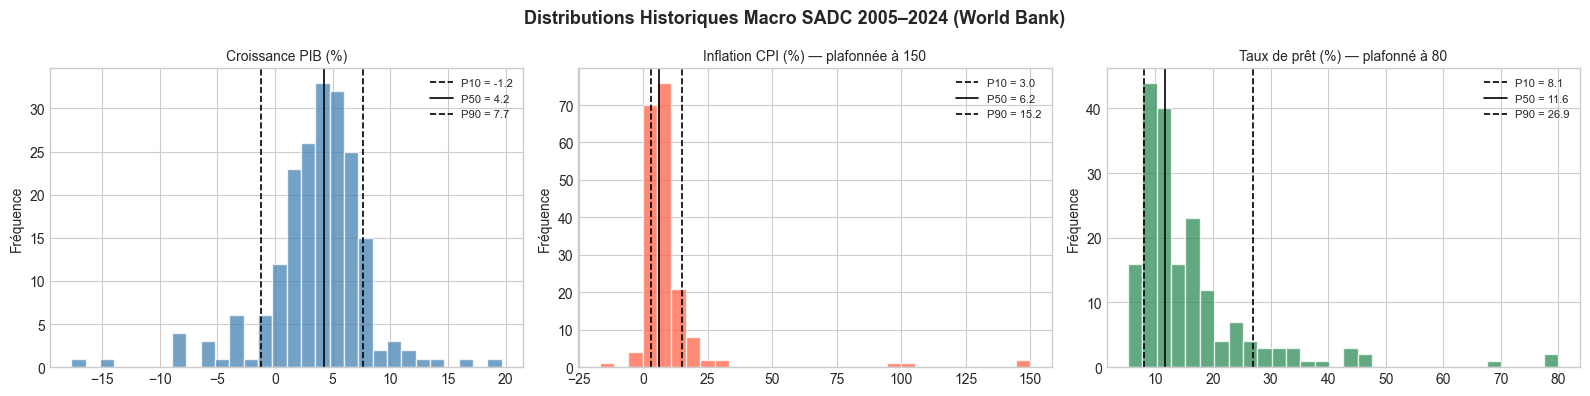

In [4]:
# ── Visualisation des distributions macro SADC ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distributions Historiques Macro SADC 2005–2024 (World Bank)', fontsize=13, fontweight='bold')

datasets = [
    (gdp_vals,  'Croissance PIB (%)',   'steelblue'),
    (cpi_vals,  'Inflation CPI (%) — plafonnée à 150', 'tomato'),
    (lend_vals, 'Taux de prêt (%) — plafonné à 80',    'seagreen'),
]
for ax, (vals, label, color) in zip(axes, datasets):
    ax.hist(vals.dropna(), bins=30, color=color, alpha=0.75, edgecolor='white')
    for p, ls in [(.10,'--'), (.50,'-'), (.90,'--')]:
        ax.axvline(vals.quantile(p), color='black', linestyle=ls, linewidth=1.2,
                   label=f'P{int(p*100)} = {vals.quantile(p):.1f}')
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Section 2 — Chargement & Audit du Dataset LGD

In [5]:
df = pd.read_csv('synthetic_sadc_lgd_dataset (1).csv')

print(f'Shape : {df.shape}')
print(f'\nTypes :\n{df.dtypes}')
print(f'\nValeurs manquantes :\n{df.isnull().sum()}')

Shape : (500, 13)

Types :
LGD                       float64
GDP_Growth_Percent        float64
Inflation_Rate_Percent    float64
Policy_Rate_Percent       float64
Exposure_at_Default       float64
Asset_Coverage_Value      float64
Lending_Rate_Percent      float64
Loan_Duration_Months        int64
Risk_Score                float64
Loan_Category                 str
Applicant_Age               int64
Employment_Status             str
Household_Income          float64
dtype: object

Valeurs manquantes :
LGD                       0
GDP_Growth_Percent        0
Inflation_Rate_Percent    0
Policy_Rate_Percent       0
Exposure_at_Default       0
Asset_Coverage_Value      0
Lending_Rate_Percent      0
Loan_Duration_Months      0
Risk_Score                0
Loan_Category             0
Applicant_Age             0
Employment_Status         0
Household_Income          0
dtype: int64


In [6]:
print('=== Statistiques descriptives ===')
df.describe(percentiles=[.10,.25,.50,.75,.90]).T.round(3)

=== Statistiques descriptives ===


,count,mean,std,min,10%,25%,50%,75%,90%,max
LGD,500.0,0.309,0.225,0.00,0.071,0.156,0.265,0.411,0.562,1.00
GDP_Growth_Percent,500.0,1.430,1.005,-1.97,0.148,0.760,1.420,2.112,2.690,4.23
Inflation_Rate_Percent,500.0,85.668,19.448,31.30,60.252,71.662,86.445,100.358,110.792,146.24
Policy_Rate_Percent,500.0,34.614,9.761,1.75,22.657,28.155,34.255,41.535,47.138,62.66
Exposure_at_Default,500.0,49732.514,20154.116,-4445.55,23447.619,35605.085,50150.395,63242.685,75418.111,102900.74
Asset_Coverage_Value,500.0,29813.975,10001.456,955.36,17810.488,23240.792,29013.580,36594.762,43207.626,56376.95
Lending_Rate_Percent,500.0,40.223,7.785,13.80,30.477,35.055,40.060,45.522,50.304,62.15
Loan_Duration_Months,500.0,33.096,15.258,6.00,12.000,19.750,33.000,46.000,54.000,59.00
Risk_Score,500.0,574.424,161.954,301.00,348.900,435.750,571.000,722.500,800.000,850.00
Applicant_Age,500.0,42.120,12.378,21.00,24.000,32.000,42.000,53.000,59.000,64.00


In [7]:
# ── Audit critique : valeurs limites de la LGD ───────────────────────────────
n = len(df)
exact_zero = (df['LGD'] == 0).sum()
exact_one  = (df['LGD'] == 1).sum()
interior   = ((df['LGD'] > 0) & (df['LGD'] < 1)).sum()

print('=== Audit des valeurs limites LGD ===')
print(f'  LGD = 0 (récupération totale) : {exact_zero:4d}  ({100*exact_zero/n:.1f}%)')
print(f'  LGD = 1 (perte totale)         : {exact_one:4d}  ({100*exact_one/n:.1f}%)')
print(f'  LGD ∈ (0, 1) — intérieur       : {interior:4d}  ({100*interior/n:.1f}%)')
print()
print('→ La transformation Smithson-Verkuilen sera appliquée pour la Régression Bêta.')

# ── Audit catégoriels ────────────────────────────────────────────────────────
print('\n=== Variables catégorielles ===')
for col in ['Loan_Category', 'Employment_Status']:
    print(f'\n{col} :')
    print(df[col].value_counts())

=== Audit des valeurs limites LGD ===
  LGD = 0 (récupération totale) :   25  (5.0%)
  LGD = 1 (perte totale)         :   25  (5.0%)
  LGD ∈ (0, 1) — intérieur       :  450  (90.0%)

→ La transformation Smithson-Verkuilen sera appliquée pour la Régression Bêta.

=== Variables catégorielles ===

Loan_Category :
Loan_Category
Personal        168
Business        167
Agricultural    165
Name: count, dtype: int64

Employment_Status :
Employment_Status
Employed         182
Self-Employed    171
Unemployed       147
Name: count, dtype: int64


In [8]:
# ── Analyse VIF (multicolinéarité) ───────────────────────────────────────────
num_cols = ['GDP_Growth_Percent','Inflation_Rate_Percent','Policy_Rate_Percent',
            'Lending_Rate_Percent','Exposure_at_Default','Asset_Coverage_Value',
            'Loan_Duration_Months','Risk_Score','Applicant_Age','Household_Income']

X_vif = sm.add_constant(df[num_cols].dropna())
vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).set_index('Variable').sort_values('VIF', ascending=False)

print('=== Variance Inflation Factor (VIF > 10 = multicolinéarité sévère) ===')
print(vif_df.round(2))

=== Variance Inflation Factor (VIF > 10 = multicolinéarité sévère) ===
                           VIF
Variable                      
const                   111.95
Exposure_at_Default       1.06
Household_Income          1.06
Policy_Rate_Percent       1.03
Risk_Score                1.03
Asset_Coverage_Value      1.03
Applicant_Age             1.02
GDP_Growth_Percent        1.02
Loan_Duration_Months      1.01
Lending_Rate_Percent      1.01
Inflation_Rate_Percent    1.00


---
## Section 3 — Analyse Exploratoire (EDA)

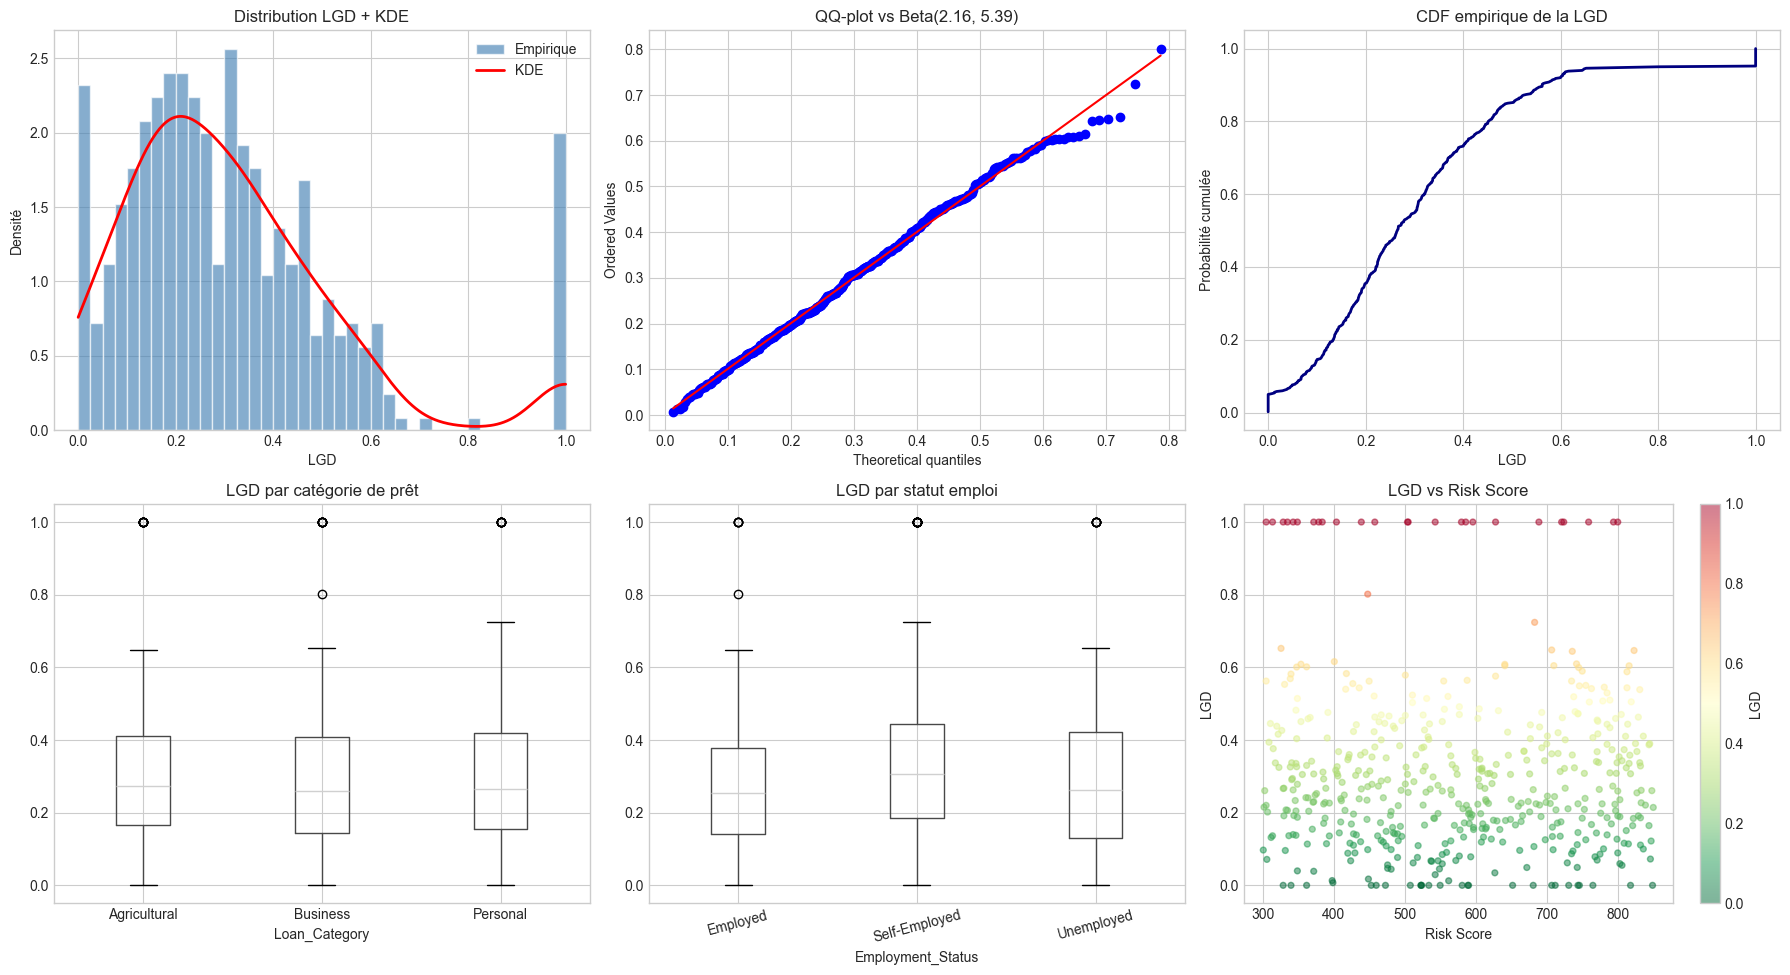

Skewness LGD : 1.354
Kurtosis LGD : 2.202


In [9]:
# ── 3.1 Distribution de la LGD ───────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Distribution de la LGD — Analyse exploratoire', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig)

# Panel 1 : Histogramme + KDE
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['LGD'], bins=40, density=True, alpha=0.65, color='steelblue',
         edgecolor='white', label='Empirique')
kde = stats.gaussian_kde(df['LGD'])
x   = np.linspace(0, 1, 300)
ax1.plot(x, kde(x), 'r-', lw=2, label='KDE')
ax1.set_xlabel('LGD'); ax1.set_ylabel('Densité')
ax1.set_title('Distribution LGD + KDE')
ax1.legend()

# Panel 2 : QQ-plot vs distribution Bêta ajustée
ax2 = fig.add_subplot(gs[0, 1])
lgd_int = df['LGD'][(df['LGD'] > 0) & (df['LGD'] < 1)]
a_fit, b_fit, _, _ = stats.beta.fit(lgd_int, floc=0, fscale=1)
stats.probplot(lgd_int, dist=stats.beta(a_fit, b_fit), plot=ax2)
ax2.set_title(f'QQ-plot vs Beta({a_fit:.2f}, {b_fit:.2f})')

# Panel 3 : CDF empirique
ax3 = fig.add_subplot(gs[0, 2])
sorted_lgd = np.sort(df['LGD'])
ecdf = np.arange(1, n+1) / n
ax3.plot(sorted_lgd, ecdf, 'navy', lw=2)
ax3.set_xlabel('LGD'); ax3.set_ylabel('Probabilité cumulée')
ax3.set_title('CDF empirique de la LGD')

# Panel 4 : Boxplot par Loan_Category
ax4 = fig.add_subplot(gs[1, 0])
df.boxplot(column='LGD', by='Loan_Category', ax=ax4)
plt.sca(ax4); plt.title('LGD par catégorie de prêt'); plt.suptitle('')

# Panel 5 : Boxplot par Employment_Status
ax5 = fig.add_subplot(gs[1, 1])
df.boxplot(column='LGD', by='Employment_Status', ax=ax5)
plt.sca(ax5); plt.title('LGD par statut emploi'); plt.suptitle('')
plt.xticks(rotation=15)

# Panel 6 : Scatter LGD vs Risk_Score
ax6 = fig.add_subplot(gs[1, 2])
sc = ax6.scatter(df['Risk_Score'], df['LGD'], c=df['LGD'],
                  cmap='RdYlGn_r', alpha=0.5, s=18)
plt.colorbar(sc, ax=ax6, label='LGD')
ax6.set_xlabel('Risk Score'); ax6.set_ylabel('LGD')
ax6.set_title('LGD vs Risk Score')

plt.tight_layout()
plt.show()

print(f'Skewness LGD : {df["LGD"].skew():.3f}')
print(f'Kurtosis LGD : {df["LGD"].kurt():.3f}')

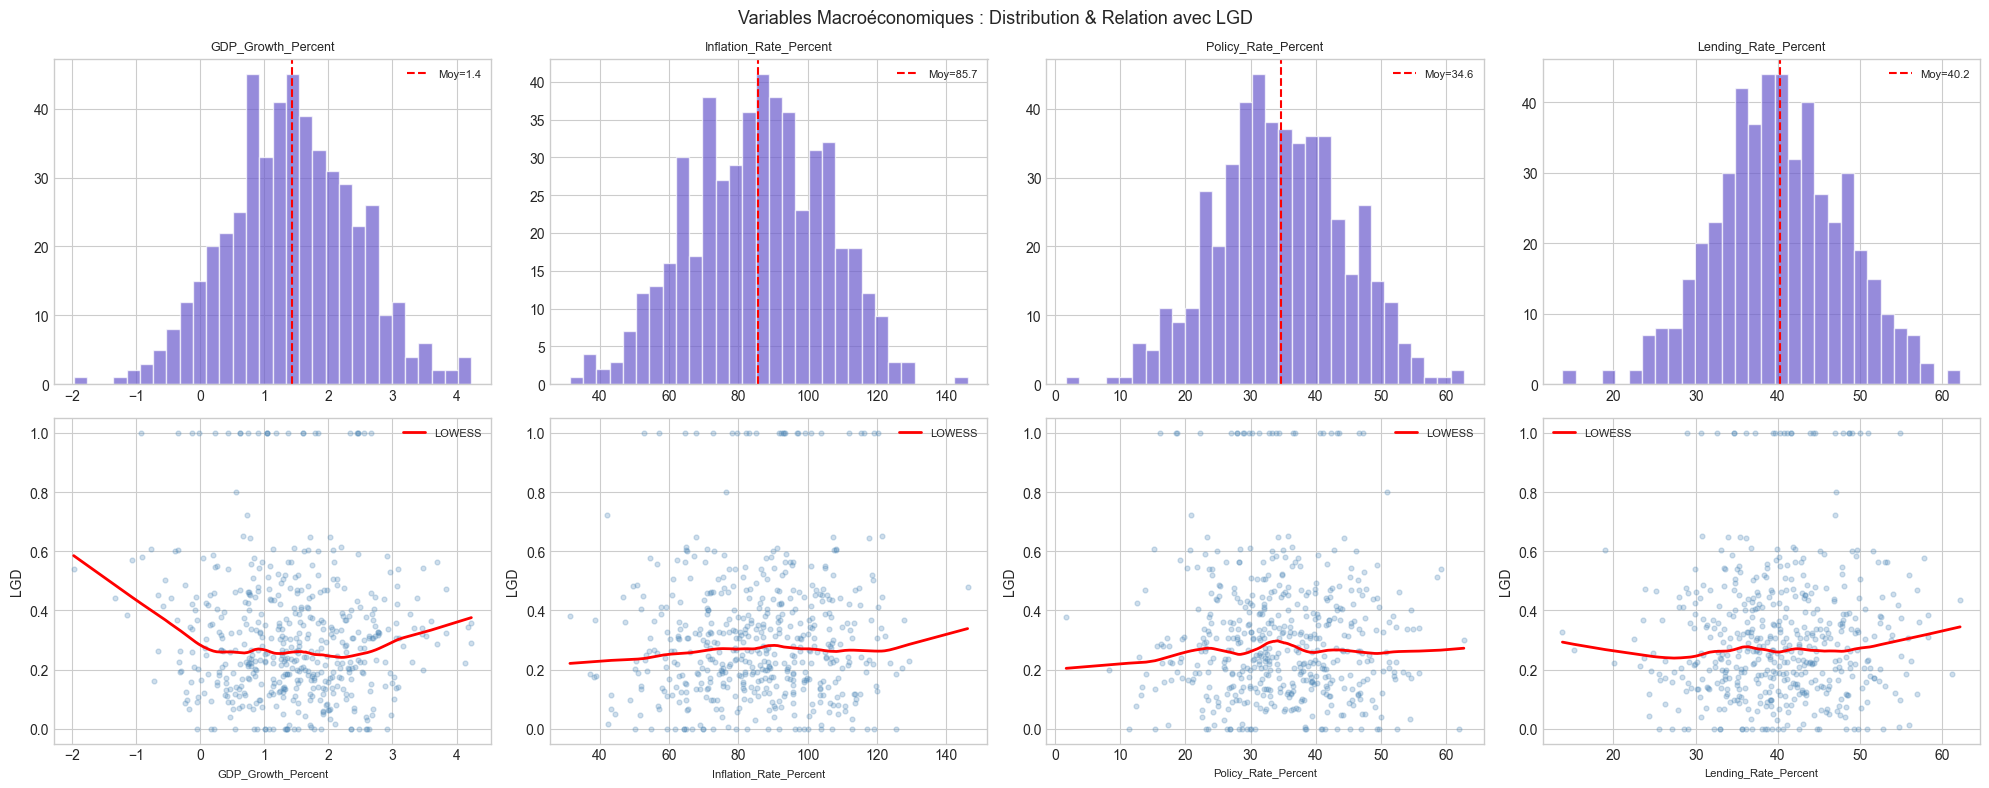

In [10]:
# ── 3.2 Variables macro vs LGD avec LOWESS ───────────────────────────────────
macro_cols = ['GDP_Growth_Percent','Inflation_Rate_Percent',
              'Policy_Rate_Percent','Lending_Rate_Percent']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Variables Macroéconomiques : Distribution & Relation avec LGD', fontsize=13)

for i, col in enumerate(macro_cols):
    # Ligne 0 : distribution
    ax = axes[0, i]
    ax.hist(df[col], bins=30, color='slateblue', alpha=0.7, edgecolor='white')
    ax.axvline(df[col].mean(), color='red', linestyle='--', lw=1.5,
               label=f'Moy={df[col].mean():.1f}')
    ax.set_title(col, fontsize=9); ax.legend(fontsize=8)

    # Ligne 1 : scatter + LOWESS
    ax = axes[1, i]
    ax.scatter(df[col], df['LGD'], alpha=0.25, s=12, color='steelblue')
    sm_fit = lowess(df['LGD'], df[col], frac=0.35)
    ax.plot(sm_fit[:, 0], sm_fit[:, 1], 'r-', lw=2, label='LOWESS')
    ax.set_xlabel(col, fontsize=8); ax.set_ylabel('LGD')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

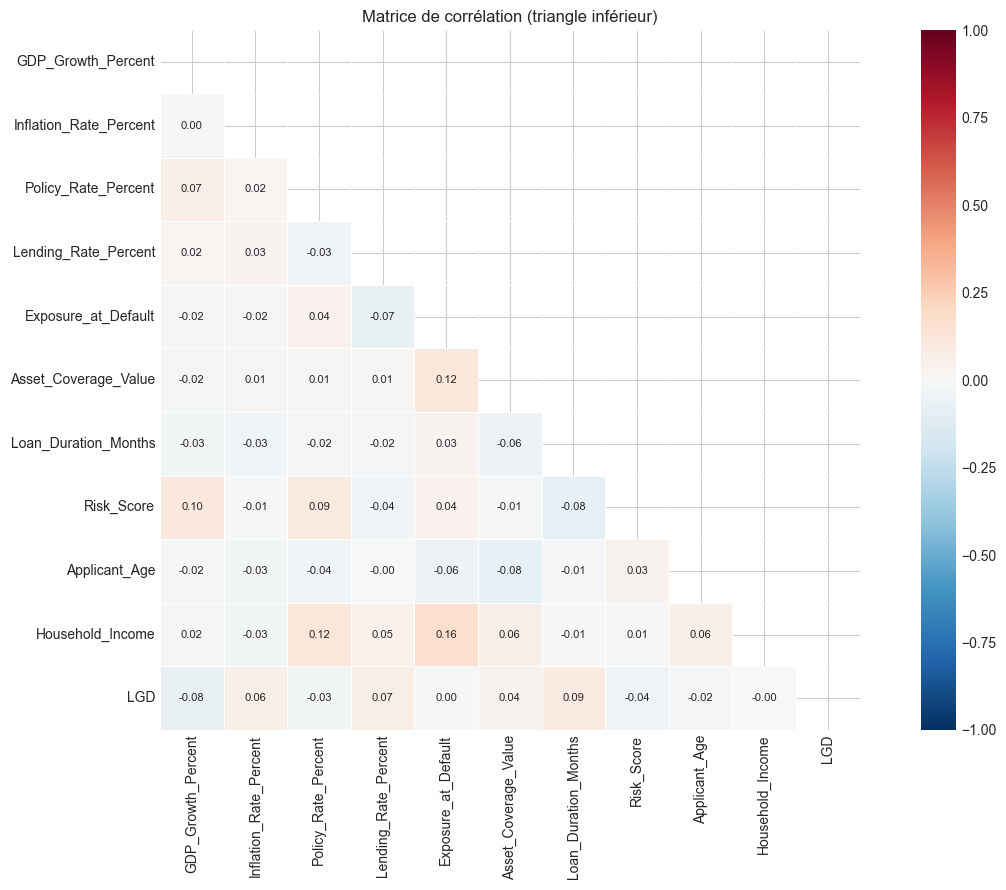


Corrélations avec LGD :
GDP_Growth_Percent       -0.075423
Risk_Score               -0.041377
Policy_Rate_Percent      -0.026940
Applicant_Age            -0.023394
Household_Income         -0.003545
Exposure_at_Default       0.000464
Asset_Coverage_Value      0.037248
Inflation_Rate_Percent    0.064701
Lending_Rate_Percent      0.068153
Loan_Duration_Months      0.090737
Name: LGD, dtype: float64


In [11]:
# ── 3.3 Matrice de corrélation ────────────────────────────────────────────────
corr = df[num_cols + ['LGD']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.4, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matrice de corrélation (triangle inférieur)', fontsize=12)
plt.tight_layout()
plt.show()

print('\nCorrélations avec LGD :')
print(corr['LGD'].drop('LGD').sort_values())

---
## Section 4 — Feature Engineering

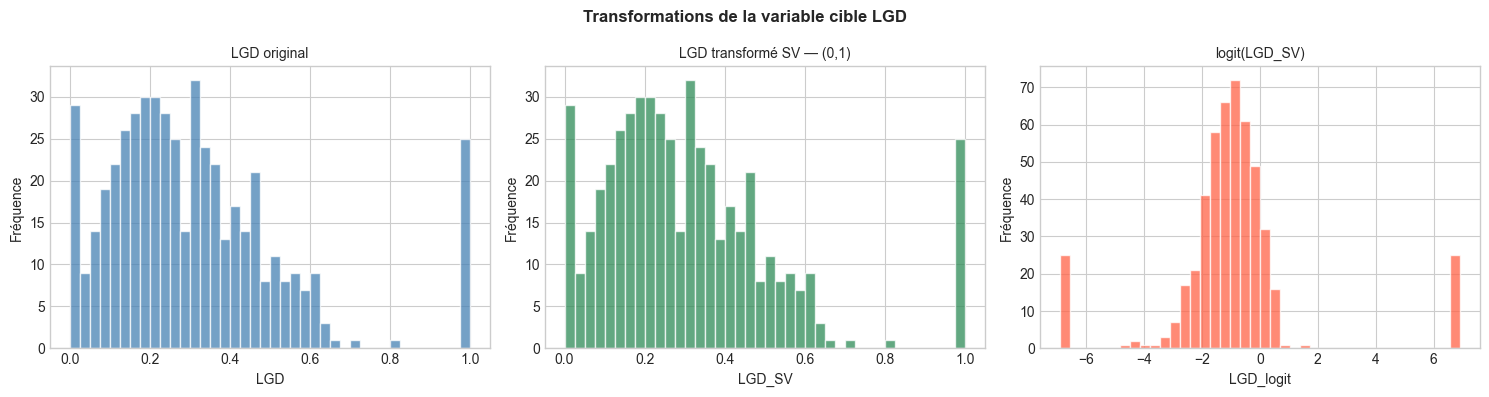

In [12]:
# ── 4.1 Transformations de la LGD ────────────────────────────────────────────
# Smithson-Verkuilen : mappe [0,1] → (0,1) strictement, sans modifier la forme
df['LGD_SV']    = (df['LGD'] * (n - 1) + 0.5) / n
# Logit : mappe (0,1) → (-∞, +∞) pour le modèle satellite OLS
df['LGD_logit'] = np.log(df['LGD_SV'] / (1 - df['LGD_SV']))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, color in zip(
        axes,
        ['LGD', 'LGD_SV', 'LGD_logit'],
        ['LGD original', 'LGD transformé SV — (0,1)', 'logit(LGD_SV)'],
        ['steelblue', 'seagreen', 'tomato']):
    ax.hist(df[col], bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')

plt.suptitle('Transformations de la variable cible LGD', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# ── 4.2 Nouvelles variables économiques ──────────────────────────────────────
# Taux réel : Lending - Inflation (peut être négatif en SADC → répression financière)
df['Real_Lending_Rate']         = df['Lending_Rate_Percent'] - df['Inflation_Rate_Percent']
# Spread banque : marge entre taux de prêt et taux directeur
df['Rate_Spread']               = df['Lending_Rate_Percent'] - df['Policy_Rate_Percent']
# Ratio de couverture par le collatéral (prédicteur théorique central — Merton 1974)
df['Collateral_Coverage_Ratio'] = (df['Asset_Coverage_Value'] / df['Exposure_at_Default']).clip(upper=10.0)
df['Undercollateralized']       = (df['Collateral_Coverage_Ratio'] < 1.0).astype(int)
# Indicateur de récession
df['Recession_Indicator']       = (df['GDP_Growth_Percent'] < 0).astype(int)
# Log-transformations des variables financières (réduire asymétrie)
df['Log_Exposure']              = np.log1p(df['Exposure_at_Default'])
df['Log_Asset_Coverage']        = np.log1p(df['Asset_Coverage_Value'])
df['Log_Income']                = np.log1p(df['Household_Income'])
df['Loan_Duration_Years']       = df['Loan_Duration_Months'] / 12

print('Variables créées :')
new_vars = ['Real_Lending_Rate','Rate_Spread','Collateral_Coverage_Ratio',
            'Undercollateralized','Recession_Indicator']
print(df[new_vars].describe().T.round(3))

Variables créées :
                           count    mean     std      min     25%     50%  \
Real_Lending_Rate          500.0 -45.444  20.724 -103.630 -60.825 -45.085   
Rate_Spread                500.0   5.609  12.677  -25.950  -2.822   5.515   
Collateral_Coverage_Ratio  500.0   0.543   4.267  -91.822   0.443   0.596   
Undercollateralized        500.0   0.830   0.376    0.000   1.000   1.000   
Recession_Indicator        500.0   0.082   0.275    0.000   0.000   0.000   

                              75%    max  
Real_Lending_Rate         -30.235  12.34  
Rate_Spread                14.818  43.05  
Collateral_Coverage_Ratio   0.842  10.00  
Undercollateralized         1.000   1.00  
Recession_Indicator         0.000   1.00  


In [14]:
# ── 4.3 Encodage one-hot des catégoriels ─────────────────────────────────────
df_enc = pd.get_dummies(df, columns=['Loan_Category','Employment_Status'],
                         drop_first=True, dtype=float)

print('Catégorie de référence — Loan_Category : Agricultural')
print('Catégorie de référence — Employment_Status : Employed')
print('\nColonnes ajoutées :', [c for c in df_enc.columns
                                if 'Loan_Category' in c or 'Employment' in c])

# ── Sets de variables ─────────────────────────────────────────────────────────
MACRO_FEATURES = ['GDP_Growth_Percent','Real_Lending_Rate',
                   'Rate_Spread','Recession_Indicator']
LOAN_FEATURES  = ['Log_Exposure','Collateral_Coverage_Ratio',
                   'Loan_Duration_Years','Log_Income','Risk_Score',
                   'Applicant_Age','Undercollateralized']
CAT_FEATURES   = [c for c in df_enc.columns
                  if 'Loan_Category' in c or 'Employment' in c]
ALL_FEATURES   = MACRO_FEATURES + LOAN_FEATURES + CAT_FEATURES

X    = df_enc[ALL_FEATURES]
y    = df_enc['LGD']
y_sv = df_enc['LGD_SV']
y_logit = df_enc['LGD_logit']

print(f'\nMatrice X : {X.shape}  |  y : {y.shape}')
# ── Nettoyage : remplacer inf et NaN (division par zéro possible dans Collateral_Coverage_Ratio) ──
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())
X_sm = sm.add_constant(X)   # recalculer X_sm propre

print(f"NaN restants dans X : {X.isnull().sum().sum()}")
print(f"Inf restants dans X : {(X == np.inf).sum().sum()}")
print(f"Matrice X propre : {X.shape}")


Catégorie de référence — Loan_Category : Agricultural
Catégorie de référence — Employment_Status : Employed

Colonnes ajoutées : ['Loan_Category_Business', 'Loan_Category_Personal', 'Employment_Status_Self-Employed', 'Employment_Status_Unemployed']

Matrice X : (500, 15)  |  y : (500,)
NaN restants dans X : 0
Inf restants dans X : 0
Matrice X propre : (500, 15)


---
## Section 5 — Développement des Modèles

Cinq méthodes spécifiques à la modélisation LGD sont comparées :
1. **Tobit** — régression censurée deux côtés
2. **Régression Bêta** — distribution naturelle pour les proportions dans (0,1)
3. **FRM** — Fractional Response Model (Papke & Wooldridge, 1996)
4. **Random Forest** — méthode ensembliste
5. **XGBoost + SHAP** — boosting avec explicabilité

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# 5.1 — RÉGRESSION TOBIT (censurée deux côtés [0, 1])
# ══════════════════════════════════════════════════════════════════════════════
# Modèle : y* ~ N(Xβ, σ²)
#   On observe y = 0 si y* ≤ 0 | y = y* si 0 < y* < 1 | y = 1 si y* ≥ 1
# Log-vraisemblance :
#   Σ_{y=0} log Φ(-Xβ/σ) + Σ_{0<y<1} log[φ((y-Xβ)/σ)/σ] + Σ_{y=1} log[1-Φ((1-Xβ)/σ)]

def tobit_nll(params, X_np, y_np, lo=0.0, hi=1.0):
    """Log-vraisemblance négative du Tobit deux côtés."""
    beta  = params[:-1]
    sigma = np.exp(params[-1])      # log-paramétrage pour garantir σ > 0
    Xb    = X_np @ beta

    mask_lo = (y_np == lo)
    mask_hi = (y_np == hi)
    mask_in = ~mask_lo & ~mask_hi

    ll = 0.0
    if mask_lo.any():
        ll += np.sum(np.log(norm.cdf((lo - Xb[mask_lo]) / sigma) + 1e-12))
    if mask_hi.any():
        ll += np.sum(np.log(1 - norm.cdf((hi - Xb[mask_hi]) / sigma) + 1e-12))
    if mask_in.any():
        ll += np.sum(norm.logpdf((y_np[mask_in] - Xb[mask_in]) / sigma) - np.log(sigma))
    return -ll

def tobit_predict(X_np, beta, sigma, lo=0.0, hi=1.0):
    """Espérance conditionnelle E[y | lo ≤ y* ≤ hi]."""
    Xb       = X_np @ beta
    al       = (lo - Xb) / sigma
    ah       = (hi - Xb) / sigma
    phi_l, phi_h = norm.pdf(al), norm.pdf(ah)
    Phi_l, Phi_h = norm.cdf(al), norm.cdf(ah)
    denom    = Phi_h - Phi_l + 1e-12
    E_in     = Xb + sigma * (phi_l - phi_h) / denom
    return np.clip(E_in * denom + lo * Phi_l + hi * (1 - Phi_h), lo, hi)

X_np  = sm.add_constant(X.values)
y_np  = y.values

# Initialisation : coefficients OLS + log(σ résiduel)
# Nettoyer X_np (remplacer inf et NaN avant OLS init)
X_np_clean = np.nan_to_num(X_np, nan=0.0, posinf=0.0, neginf=0.0)
try:
    ols_init = np.linalg.lstsq(X_np_clean, y_np, rcond=None)[0]
except np.linalg.LinAlgError:
    ols_init = np.zeros(X_np_clean.shape[1])
X_np = X_np_clean  # utiliser la version nettoyée
sig_init  = np.log(np.std(y_np - X_np @ ols_init) + 1e-6)
p0        = np.append(ols_init, sig_init)

res_tobit = minimize(tobit_nll, p0, args=(X_np, y_np),
                      method='L-BFGS-B', options={'maxiter': 2000, 'ftol': 1e-10})

beta_tobit  = res_tobit.x[:-1]
sigma_tobit = np.exp(res_tobit.x[-1])
y_pred_tobit = tobit_predict(X_np, beta_tobit, sigma_tobit)

print(f'Tobit convergé : {res_tobit.success}')
print(f'σ estimé       : {sigma_tobit:.4f}')
print(f'Log-vraisemblance : {-res_tobit.fun:.2f}')

Tobit convergé : True
σ estimé       : 0.2401
Log-vraisemblance : -66.15


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# 5.2 — RÉGRESSION BÊTA (Ferrari & Cribari-Neto, 2004)
# ══════════════════════════════════════════════════════════════════════════════
# y ~ Beta(μφ, (1-μ)φ)  |  logit(μ) = Xβ
# Utilise LGD_SV (transformation Smithson-Verkuilen) pour éviter les valeurs limites

beta_model  = BetaModel(y_sv, X_sm)
beta_result = beta_model.fit(disp=False, maxiter=200)

y_pred_beta = beta_result.predict(X_sm)

print('=== Régression Bêta ===')
print(beta_result.summary())

=== Régression Bêta ===
                              BetaModel Results                               
Dep. Variable:                 LGD_SV   Log-Likelihood:                 82.879
Model:                      BetaModel   AIC:                            -131.8
Method:            Maximum Likelihood   BIC:                            -60.11
Date:                Sun, 12 Apr 2026                                         
Time:                        17:38:06                                         
No. Observations:                 500                                         
Df Residuals:                     483                                         
Df Model:                          15                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -1.5630      1.556     -1.005 

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# 5.3 — FRACTIONAL RESPONSE MODEL — FRM (Papke & Wooldridge, 1996)
# ══════════════════════════════════════════════════════════════════════════════
# GLM Bernoulli avec lien logit + erreurs robustes HC3
# Avantage : gère y=0 et y=1 sans transformation, robuste à la mauvaise
#            spécification de la variance (quasi-vraisemblance)

frm_model  = sm.GLM(y, X_sm,
                     family=sm.families.Binomial(link=sm.families.links.Logit()))
frm_result = frm_model.fit(cov_type='HC3')

y_pred_frm = frm_result.predict(X_sm)

# Test de surdispersion (quasi-binomial)
frm_quasi  = sm.GLM(y, X_sm,
                     family=sm.families.Binomial(link=sm.families.links.Logit()))
frm_quasi_result = frm_quasi.fit(scale='X2')

print('=== Fractional Response Model (FRM) ===')
print(frm_result.summary())
print(f'\nParamètre de dispersion (quasi-binomial) : {frm_quasi_result.scale:.4f}')
print('(>> 1 → surdispersion présente, quasi-binomial approprié)')

=== Fractional Response Model (FRM) ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:                    LGD   No. Observations:                  500
Model:                            GLM   Df Residuals:                      484
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -226.76
Date:                Sun, 12 Apr 2026   Deviance:                       126.40
Time:                        17:38:06   Pearson chi2:                     111.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.01175
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

RF — CV RMSE : 0.2217 ± 0.0168


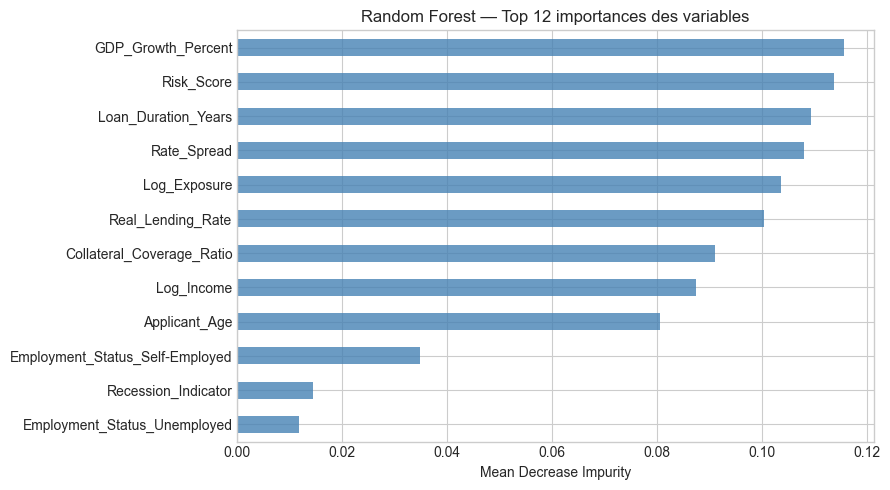

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# 5.4 — RANDOM FOREST
# ══════════════════════════════════════════════════════════════════════════════
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_model = RandomForestRegressor(
    n_estimators=500, max_depth=8, min_samples_leaf=10,
    max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1
)

rf_cv = cross_val_score(rf_model, X, y, cv=kf,
                         scoring='neg_root_mean_squared_error')
print(f'RF — CV RMSE : {-rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

rf_model.fit(X, y)
y_pred_rf = np.clip(rf_model.predict(X), 0, 1)

# Importance des variables
fi_rf = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
fi_rf.head(12).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.invert_yaxis()
ax.set_title('Random Forest — Top 12 importances des variables')
ax.set_xlabel('Mean Decrease Impurity')
plt.tight_layout()
plt.show()

XGB — CV RMSE : 0.2295 ± 0.0113


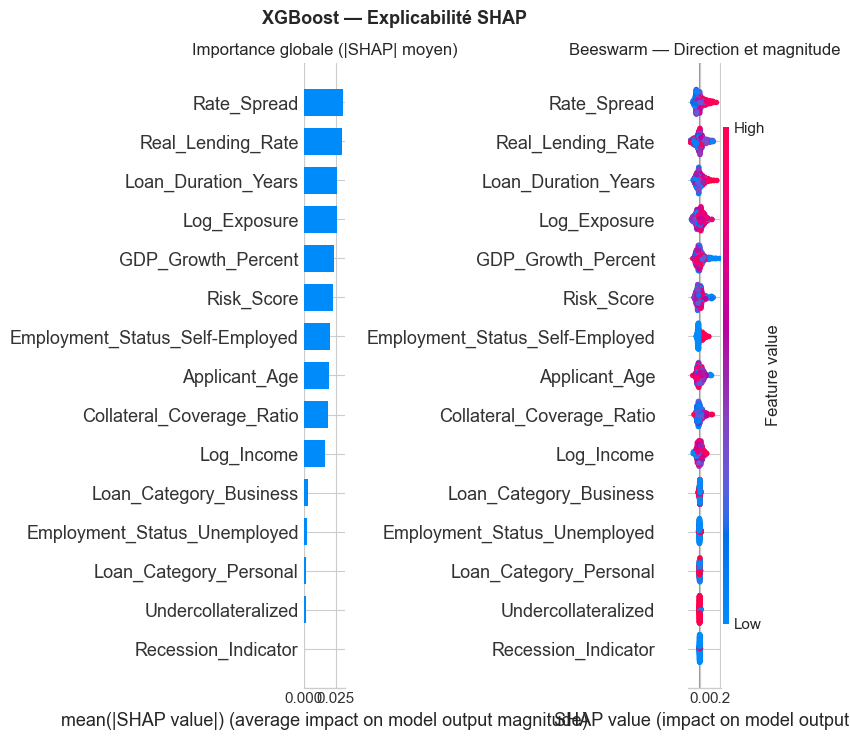

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# 5.5 — XGBOOST + SHAP
# ══════════════════════════════════════════════════════════════════════════════
xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    objective='reg:squarederror',
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)

xgb_cv = cross_val_score(xgb_model, X, y, cv=kf,
                          scoring='neg_root_mean_squared_error')
print(f'XGB — CV RMSE : {-xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')

xgb_model.fit(X, y)
y_pred_xgb = np.clip(xgb_model.predict(X), 0, 1)

# ── SHAP ─────────────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('XGBoost — Explicabilité SHAP', fontsize=13, fontweight='bold')

plt.sca(axes[0])
shap.summary_plot(shap_values, X, plot_type='bar', show=False)
axes[0].set_title('Importance globale (|SHAP| moyen)')

plt.sca(axes[1])
shap.summary_plot(shap_values, X, show=False)
axes[1].set_title('Beeswarm — Direction et magnitude')

plt.tight_layout()
plt.show()

---
## Section 6 — Modèle Satellite Macroéconomique

Le **modèle satellite** relie les variables macro à la LGD pour permettre la projection sous scénarios.  
Il utilise **uniquement** les variables macroéconomiques comme prédicteurs, isolant le risque systémique du risque idiosyncratique.

In [20]:
X_sat = sm.add_constant(df_enc[MACRO_FEATURES])

# ── OLS sur logit(LGD) ────────────────────────────────────────────────────────
sat_ols    = OLS(y_logit, X_sat).fit(cov_type='HC3')
print('=== Modèle Satellite — OLS sur logit(LGD) ===')
print(sat_ols.summary())

=== Modèle Satellite — OLS sur logit(LGD) ===
                            OLS Regression Results                            
Dep. Variable:              LGD_logit   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.418
Date:                Sun, 12 Apr 2026   Prob (F-statistic):              0.227
Time:                        17:38:10   Log-Likelihood:                -1135.5
No. Observations:                 500   AIC:                             2281.
Df Residuals:                     495   BIC:                             2302.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

In [21]:
# ── FRM satellite ─────────────────────────────────────────────────────────────
sat_frm    = sm.GLM(y, X_sat,
                     family=sm.families.Binomial(link=sm.families.links.Logit()))
sat_frm_r  = sat_frm.fit(cov_type='HC3')
print('=== Modèle Satellite — FRM ===')
print(sat_frm_r.summary())

=== Modèle Satellite — FRM ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:                    LGD   No. Observations:                  500
Model:                            GLM   Df Residuals:                      495
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -228.64
Date:                Sun, 12 Apr 2026   Deviance:                       130.17
Time:                        17:38:10   Pearson chi2:                     116.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.004278
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
con

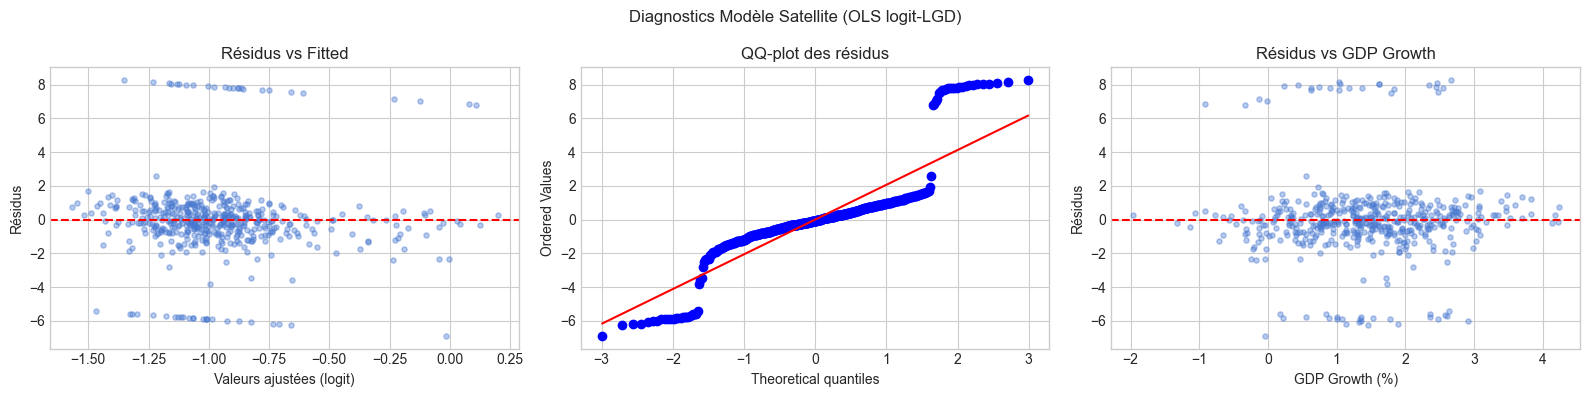

Test Breusch-Pagan : stat = 2.229, p-value = 0.6936
→ p ≥ 0.05 : pas d'hétéroscédasticité significative


In [22]:
# ── Diagnostics du modèle satellite ──────────────────────────────────────────
sat_resid  = sat_ols.resid
sat_fitted = sat_ols.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Diagnostics Modèle Satellite (OLS logit-LGD)', fontsize=12)

# Résidus vs fitted
axes[0].scatter(sat_fitted, sat_resid, alpha=0.4, s=14)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valeurs ajustées (logit)'); axes[0].set_ylabel('Résidus')
axes[0].set_title('Résidus vs Fitted')

# QQ-plot
stats.probplot(sat_resid, plot=axes[1])
axes[1].set_title('QQ-plot des résidus')

# Résidus vs GDP_Growth
axes[2].scatter(df_enc['GDP_Growth_Percent'], sat_resid, alpha=0.4, s=14)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('GDP Growth (%)'); axes[2].set_ylabel('Résidus')
axes[2].set_title('Résidus vs GDP Growth')

plt.tight_layout()
plt.show()

# Test de Breusch-Pagan
bp_stat, bp_pval, _, _ = het_breuschpagan(sat_resid, X_sat)
print(f'Test Breusch-Pagan : stat = {bp_stat:.3f}, p-value = {bp_pval:.4f}')
print('→ p < 0.05 : hétéroscédasticité → erreurs HC3 justifiées' if bp_pval < 0.05
      else '→ p ≥ 0.05 : pas d\'hétéroscédasticité significative')

---
## Section 7 — Scénarios Forward-Looking (IFRS 9)

Les **3 scénarios** sont calibrés sur les percentiles historiques réels SADC (Section 1) :  
- **Baseline (50%)** : conditions proches de la médiane historique  
- **Adverse (30%)** : ralentissement économique, pressions sur les taux  
- **Severely Adverse (20%)** : récession profonde, taux réels fortement négatifs

In [23]:
# ── Calcul des références World Bank pour chaque variable macro du modèle ────
# GDP_Growth_Percent  → percentiles du GDP_Growth WB
# Real_Lending_Rate   → taux prêt WB - inflation WB (par pays-année)
# Rate_Spread         → approximé via le spread dans le dataset synthétique
#                       (WB ne fournit pas le taux directeur par défaut)

# Merge GDP + CPI + Lending par pays-année
wb_merged = (
    wb['GDP_Growth'].rename(columns={'value': 'gdp'})
    .merge(wb['Inflation_CPI'].rename(columns={'value': 'cpi'}),
           on=['country','iso3','year'])
    .merge(wb['Lending_Rate'].rename(columns={'value': 'lend'}),
           on=['country','iso3','year'])
)
wb_merged['real_rate'] = wb_merged['lend'] - wb_merged['cpi']

# Plafonner les extrêmes
wb_merged = wb_merged[
    (wb_merged['cpi'] <= 150) &
    (wb_merged['lend'] <= 80)
]

# Percentiles pour chaque variable
gdp_q  = wb_merged['gdp'].quantile
rr_q   = wb_merged['real_rate'].quantile

# Rate_Spread : utiliser les percentiles du dataset synthétique
rs_q   = df_enc['Rate_Spread'].quantile

print('Calibration des scénarios (percentiles SADC historiques) :')
print(f"  GDP Growth  : P10={gdp_q(.10):.2f}  P25={gdp_q(.25):.2f}  P50={gdp_q(.50):.2f}  P75={gdp_q(.75):.2f}  P90={gdp_q(.90):.2f}")
print(f"  Real Rate   : P10={rr_q(.10):.2f}  P25={rr_q(.25):.2f}  P50={rr_q(.50):.2f}  P75={rr_q(.75):.2f}  P90={rr_q(.90):.2f}")
print(f"  Rate Spread : P10={rs_q(.10):.2f}  P25={rs_q(.25):.2f}  P50={rs_q(.50):.2f}  P75={rs_q(.75):.2f}  P90={rs_q(.90):.2f}")

Calibration des scénarios (percentiles SADC historiques) :
  GDP Growth  : P10=0.05  P25=1.97  P50=4.19  P75=6.07  P90=7.65
  Real Rate   : P10=2.34  P25=3.82  P50=5.66  P75=10.19  P90=16.14
  Rate Spread : P10=-10.81  P25=-2.82  P50=5.52  P75=14.82  P90=22.60


In [24]:
# ── Définition des 3 scénarios ───────────────────────────────────────────────
scenarios = {
    'Baseline': {
        'GDP_Growth_Percent': gdp_q(.50),
        'Real_Lending_Rate':  rr_q(.50),
        'Rate_Spread':        rs_q(.50),
        'Recession_Indicator': 0,
        'Probability': 0.50,
        'Narrative': 'Conditions proches de la médiane historique SADC'
    },
    'Adverse': {
        'GDP_Growth_Percent': gdp_q(.25),
        'Real_Lending_Rate':  rr_q(.75),
        'Rate_Spread':        rs_q(.75),
        'Recession_Indicator': 0,
        'Probability': 0.30,
        'Narrative': 'Ralentissement économique, pressions inflationnistes (quartile bas PIB)'
    },
    'Severely Adverse': {
        'GDP_Growth_Percent': gdp_q(.10),
        'Real_Lending_Rate':  rr_q(.90),
        'Rate_Spread':        rs_q(.90),
        'Recession_Indicator': 1,
        'Probability': 0.20,
        'Narrative': 'Récession profonde, taux réels fortement négatifs (décile bas PIB)'
    }
}

assert abs(sum(s['Probability'] for s in scenarios.values()) - 1.0) < 1e-9

print('=== Définition des scénarios forward-looking ===')
for name, s in scenarios.items():
    print(f"\n{name} (poids {s['Probability']:.0%}) — {s['Narrative']}")
    print(f"  GDP Growth      : {s['GDP_Growth_Percent']:.2f}%")
    print(f"  Real Lend. Rate : {s['Real_Lending_Rate']:.2f}%")
    print(f"  Rate Spread     : {s['Rate_Spread']:.2f}%")
    print(f"  Récession       : {'Oui' if s['Recession_Indicator'] else 'Non'}")

=== Définition des scénarios forward-looking ===

Baseline (poids 50%) — Conditions proches de la médiane historique SADC
  GDP Growth      : 4.19%
  Real Lend. Rate : 5.66%
  Rate Spread     : 5.52%
  Récession       : Non

Adverse (poids 30%) — Ralentissement économique, pressions inflationnistes (quartile bas PIB)
  GDP Growth      : 1.97%
  Real Lend. Rate : 10.19%
  Rate Spread     : 14.82%
  Récession       : Non

Severely Adverse (poids 20%) — Récession profonde, taux réels fortement négatifs (décile bas PIB)
  GDP Growth      : 0.05%
  Real Lend. Rate : 16.14%
  Rate Spread     : 22.60%
  Récession       : Oui


In [25]:
# ── Calcul LGD par scénario via le modèle satellite ──────────────────────────
for name, s in scenarios.items():
    X_s = pd.DataFrame([{f: s[f] for f in MACRO_FEATURES}])
    X_s = sm.add_constant(X_s, has_constant='add')
    logit_lgd = sat_ols.predict(X_s).values[0]
    s['LGD_logit'] = logit_lgd
    s['LGD']       = float(expit(logit_lgd))

# LGD pondérée probabilisée
FL_LGD      = sum(s['LGD'] * s['Probability'] for s in scenarios.values())
HIST_LGD    = float(y.mean())
FL_ADJ      = FL_LGD - HIST_LGD

print('=== LGD par scénario ===')
for name, s in scenarios.items():
    print(f"  {name:<20} : LGD = {s['LGD']:.4f}  (logit = {s['LGD_logit']:.4f})")
print(f"\n  LGD FL pondérée        : {FL_LGD:.4f}")
print(f"  LGD historique (PiT)   : {HIST_LGD:.4f}")
print(f"  Ajustement FL          : {FL_ADJ:+.4f}")

=== LGD par scénario ===
  Baseline             : LGD = 0.2010  (logit = -1.3799)
  Adverse              : LGD = 0.2301  (logit = -1.2078)
  Severely Adverse     : LGD = 0.4190  (logit = -0.3271)

  LGD FL pondérée        : 0.2533
  LGD historique (PiT)   : 0.3086
  Ajustement FL          : -0.0553


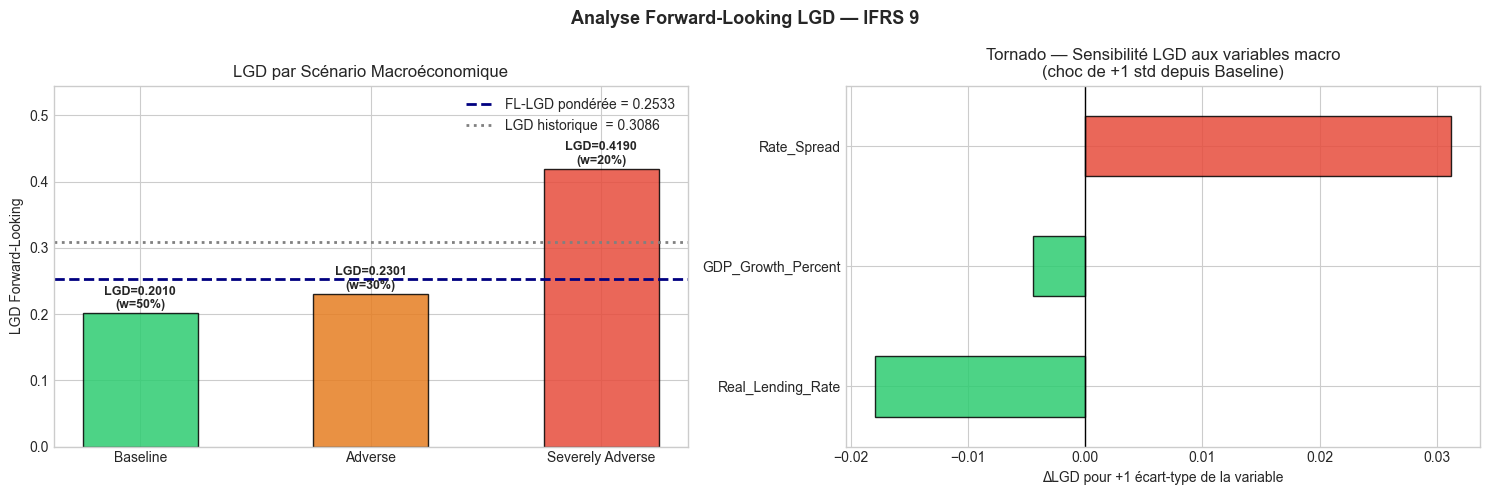

In [26]:
# ── Visualisation des scénarios ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Analyse Forward-Looking LGD — IFRS 9', fontsize=13, fontweight='bold')

# Panel 1 : LGD par scénario
ax = axes[0]
names  = list(scenarios.keys())
lgds   = [scenarios[n]['LGD'] for n in names]
probs  = [scenarios[n]['Probability'] for n in names]
colors = ['#2ecc71', '#e67e22', '#e74c3c']

bars = ax.bar(names, lgds, color=colors, alpha=0.85, edgecolor='black', width=0.5)
ax.axhline(FL_LGD,   color='navy',  linestyle='--', lw=2,
           label=f'FL-LGD pondérée = {FL_LGD:.4f}')
ax.axhline(HIST_LGD, color='gray',  linestyle=':',  lw=2,
           label=f'LGD historique  = {HIST_LGD:.4f}')

for bar, lgd, p in zip(bars, lgds, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'LGD={lgd:.4f}\n(w={p:.0%})', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('LGD Forward-Looking')
ax.set_title('LGD par Scénario Macroéconomique')
ax.set_ylim(0, max(lgds) * 1.3)
ax.legend()

# Panel 2 : Tornado — sensibilité de la LGD à chaque variable macro (+1 std)
ax = axes[1]
base_lgd = scenarios['Baseline']['LGD']
sensitivity = {}

for feat in MACRO_FEATURES:
    if feat == 'Recession_Indicator':
        continue
    base_vals = {f: scenarios['Baseline'][f] for f in MACRO_FEATURES}
    perturbed = base_vals.copy()
    perturbed[feat] = base_vals[feat] + df_enc[feat].std()
    X_p = pd.DataFrame([perturbed])
    X_p = sm.add_constant(X_p, has_constant='add')
    lgd_p = float(expit(sat_ols.predict(X_p).values[0]))
    sensitivity[feat] = lgd_p - base_lgd

sens = pd.Series(sensitivity).sort_values()
c_bar = ['#e74c3c' if v > 0 else '#2ecc71' for v in sens.values]
sens.plot(kind='barh', ax=ax, color=c_bar, alpha=0.85, edgecolor='black')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('ΔLGD pour +1 écart-type de la variable')
ax.set_title('Tornado — Sensibilité LGD aux variables macro\n(choc de +1 std depuis Baseline)')

plt.tight_layout()
plt.show()

---
## Section 8 — Validation & Comparaison des Modèles

In [27]:
# ── Métriques de validation ───────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, model_name):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    bias = float(np.mean(y_pred - y_true))

    # Coefficient de Gini (pouvoir discriminant via courbe de Lorenz)
    idx        = np.argsort(y_pred)
    lgd_sorted = y_true[idx]
    cum_lgd    = np.cumsum(lgd_sorted) / (lgd_sorted.sum() + 1e-12)
    n_         = len(y_true)
    gini       = abs(2 * cum_lgd.sum() / n_ - 1 - 1/n_)

    return {'Modèle': model_name, 'RMSE': rmse, 'MAE': mae,
            'R²': r2, 'Gini': gini, 'Biais': bias}

predictions = {
    'Tobit':        y_pred_tobit,
    'Beta Reg.':    y_pred_beta,
    'FRM':          y_pred_frm,
    'Random Forest': y_pred_rf,
    'XGBoost':      y_pred_xgb,
}

metrics_df = pd.DataFrame(
    [compute_metrics(y, pred, name) for name, pred in predictions.items()]
).set_index('Modèle').round(5)

print('=== Tableau de comparaison des modèles ===')
print(metrics_df.to_string())

metrics_df.to_csv('model_comparison.csv')
print('\n→ Exporté dans model_comparison.csv')

=== Tableau de comparaison des modèles ===
                  RMSE      MAE       R²     Gini    Biais
Modèle                                                    
Tobit          0.21875  0.16511  0.04920  0.09002  0.01022
Beta Reg.      0.22809  0.18336 -0.03375  0.08257  0.06286
FRM            0.21840  0.16291  0.05223  0.09019  0.00000
Random Forest  0.19482  0.14285  0.24584  0.29025  0.00042
XGBoost        0.06534  0.04937  0.91516  0.37202 -0.00030



→ Exporté dans model_comparison.csv


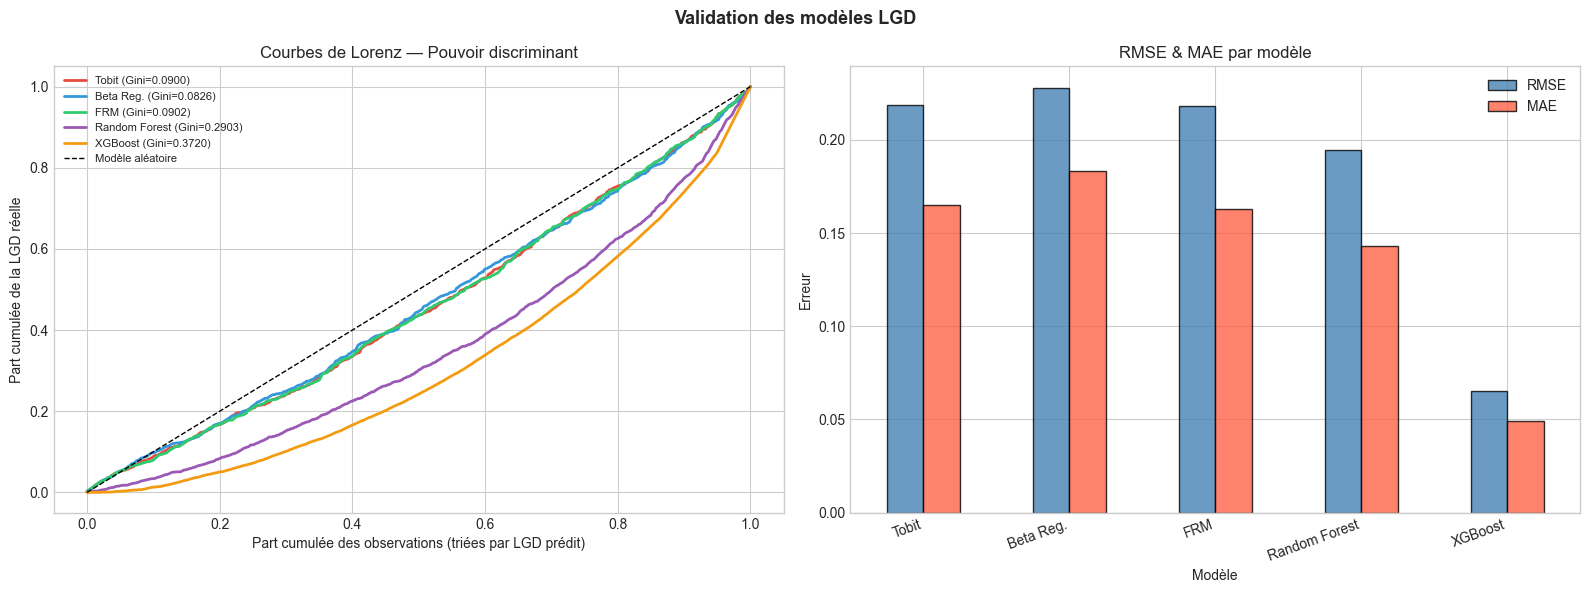

In [28]:
# ── Courbes de Lorenz (pouvoir discriminant) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Validation des modèles LGD', fontsize=13, fontweight='bold')

model_colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12']

ax = axes[0]
for (name, pred), color in zip(predictions.items(), model_colors):
    idx        = np.argsort(np.array(pred))
    lgd_sorted = np.array(y)[idx]
    cum_lgd    = np.cumsum(lgd_sorted) / lgd_sorted.sum()
    x_vals     = np.linspace(0, 1, len(cum_lgd))
    gini_val   = metrics_df.loc[name, 'Gini']
    ax.plot(x_vals, cum_lgd, color=color, lw=2,
            label=f'{name} (Gini={gini_val:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Modèle aléatoire')
ax.set_xlabel('Part cumulée des observations (triées par LGD prédit)')
ax.set_ylabel('Part cumulée de la LGD réelle')
ax.set_title('Courbes de Lorenz — Pouvoir discriminant')
ax.legend(loc='upper left', fontsize=8)

# ── Comparaison RMSE / MAE / R² ───────────────────────────────────────────────
ax = axes[1]
metrics_df[['RMSE','MAE']].plot(kind='bar', ax=ax, color=['steelblue','tomato'],
                                 alpha=0.8, edgecolor='black')
ax.set_title('RMSE & MAE par modèle')
ax.set_ylabel('Erreur')
ax.set_xticklabels(metrics_df.index, rotation=20, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

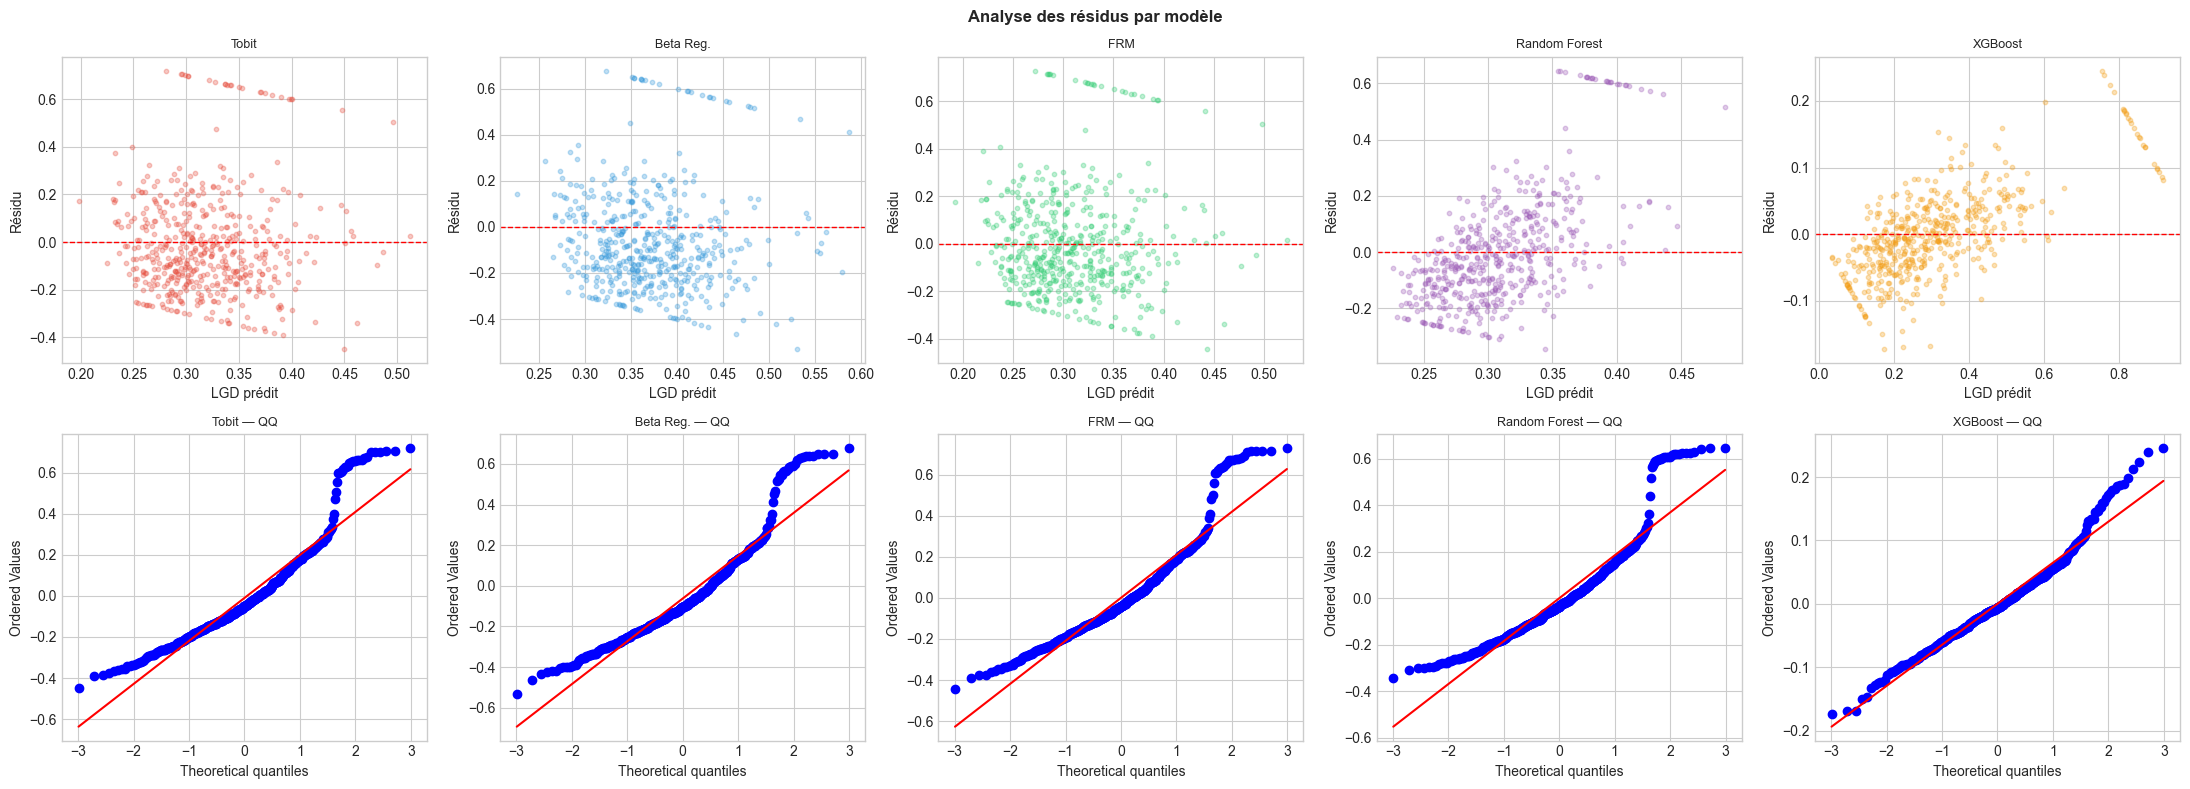

In [29]:
# ── Analyse des résidus (grille 2 × 5) ───────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Analyse des résidus par modèle', fontsize=12, fontweight='bold')

for i, (name, pred) in enumerate(predictions.items()):
    resid = np.array(y) - np.array(pred)

    # Résidus vs fitted
    axes[0, i].scatter(pred, resid, alpha=0.3, s=10, color=model_colors[i])
    axes[0, i].axhline(0, color='red', linestyle='--', lw=1)
    axes[0, i].set_xlabel('LGD prédit'); axes[0, i].set_ylabel('Résidu')
    axes[0, i].set_title(name, fontsize=9)

    # QQ-plot
    stats.probplot(resid, plot=axes[1, i])
    axes[1, i].set_title(f'{name} — QQ', fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 9 — Synthèse Réglementaire IFRS 9

In [30]:
# ── Tableau final IFRS 9 ─────────────────────────────────────────────────────
rows = []
for name, s in scenarios.items():
    rows.append({
        'Scénario':      name,
        'Poids':         f"{s['Probability']:.0%}",
        'LGD scénario':  round(s['LGD'], 4),
        'LGD pondérée':  round(s['LGD'] * s['Probability'], 4),
        'Narrative':     s['Narrative']
    })

ifrs9_df = pd.DataFrame(rows)
print('=' * 75)
print('   TABLEAU IFRS 9 — LGD FORWARD-LOOKING PONDÉRÉE')
print('=' * 75)
print(ifrs9_df[['Scénario','Poids','LGD scénario','LGD pondérée']].to_string(index=False))
print('-' * 75)
print(f"{'FL-LGD Pondérée (Σ)':<35} {'':>8} {'':>13} {FL_LGD:.4f}")
print(f"{'LGD Historique PiT (Through-the-Cycle)':<35} {'':>8} {'':>13} {HIST_LGD:.4f}")
print(f"{'Ajustement Forward-Looking':<35} {'':>8} {'':>13} {FL_ADJ:+.4f}")
print('=' * 75)

   TABLEAU IFRS 9 — LGD FORWARD-LOOKING PONDÉRÉE
        Scénario Poids  LGD scénario  LGD pondérée
        Baseline   50%        0.2010        0.1005
         Adverse   30%        0.2301        0.0690
Severely Adverse   20%        0.4190        0.0838
---------------------------------------------------------------------------
FL-LGD Pondérée (Σ)                                        0.2533
LGD Historique PiT (Through-the-Cycle)                        0.3086
Ajustement Forward-Looking                                 -0.0553


In [31]:
# ── Recommandation de modèle (grille réglementaire) ──────────────────────────
print('=== GRILLE DE SÉLECTION DE MODÈLE (Bâle III / BCBS) ===')
reco = pd.DataFrame([
    {'Modèle': 'Tobit',         'Variable bornée': 'Oui',   'Interprétable': 'Oui',     'IC disponibles': 'Non', 'Limite principale': 'Normalité de y* requise'},
    {'Modèle': 'Régression Bêta','Variable bornée':'Oui*', 'Interprétable': 'Oui',     'IC disponibles': 'Oui', 'Limite principale': 'Échoue sans transfo SV'},
    {'Modèle': 'FRM',            'Variable bornée':'Oui',   'Interprétable': 'Oui',     'IC disponibles': 'Oui', 'Limite principale': 'Variance non modélisée'},
    {'Modèle': 'Random Forest',  'Variable bornée':'Oui**','Interprétable': 'Partiel', 'IC disponibles': 'Non', 'Limite principale': 'Boîte noire, pas d\'IC'},
    {'Modèle': 'XGBoost',        'Variable bornée':'Oui**','Interprétable': 'SHAP',    'IC disponibles': 'Non', 'Limite principale': 'Surapprentissage n=500'},
])
print(reco.to_string(index=False))
print('\n* Avec transformation Smithson-Verkuilen')
print('** Après clipping sur [0,1]')
print()
print('RECOMMANDATION MODÈLE PRINCIPAL : Régression Bêta ou FRM')
print('  → Fondement théorique solide pour y ∈ (0,1)')
print('  → Coefficients interprétables + intervalles de confiance')
print('  → Exigés par le BCBS (transparence du modèle)')
print()
print('RECOMMANDATION BENCHMARK     : XGBoost + SHAP')
print('  → Comparer les prédictions; documenter toute divergence significative')

=== GRILLE DE SÉLECTION DE MODÈLE (Bâle III / BCBS) ===
         Modèle Variable bornée Interprétable IC disponibles       Limite principale
          Tobit             Oui           Oui            Non Normalité de y* requise
Régression Bêta            Oui*           Oui            Oui  Échoue sans transfo SV
            FRM             Oui           Oui            Oui  Variance non modélisée
  Random Forest           Oui**       Partiel            Non   Boîte noire, pas d'IC
        XGBoost           Oui**          SHAP            Non  Surapprentissage n=500

* Avec transformation Smithson-Verkuilen
** Après clipping sur [0,1]

RECOMMANDATION MODÈLE PRINCIPAL : Régression Bêta ou FRM
  → Fondement théorique solide pour y ∈ (0,1)
  → Coefficients interprétables + intervalles de confiance
  → Exigés par le BCBS (transparence du modèle)

RECOMMANDATION BENCHMARK     : XGBoost + SHAP
  → Comparer les prédictions; documenter toute divergence significative


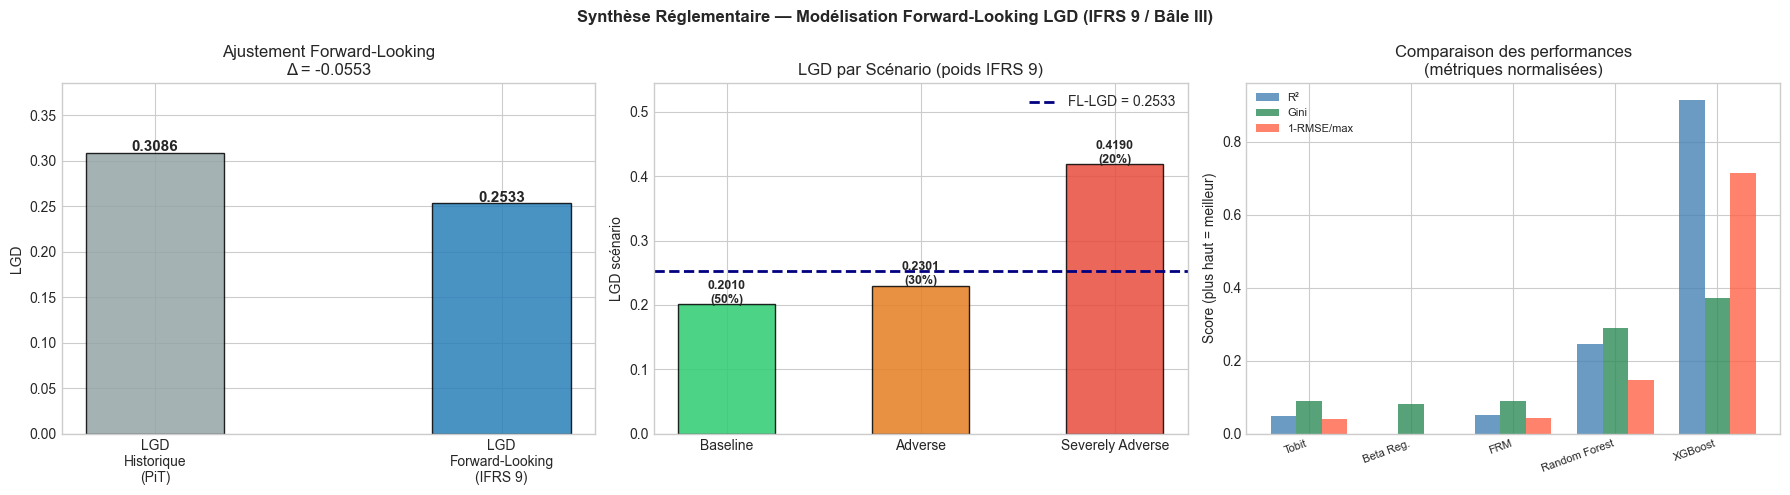


✓ Notebook complet — Forward-Looking LGD modélisé avec succès.


In [32]:
# ── Figure de synthèse finale ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Synthèse Réglementaire — Modélisation Forward-Looking LGD (IFRS 9 / Bâle III)',
             fontsize=12, fontweight='bold')

# Panel 1 : LGD FL pondérée vs historique
ax = axes[0]
vals  = [HIST_LGD, FL_LGD]
lbls  = ['LGD\nHistorique\n(PiT)', 'LGD\nForward-Looking\n(IFRS 9)']
cols  = ['#95a5a6', '#2980b9']
bars  = ax.bar(lbls, vals, color=cols, alpha=0.85, edgecolor='black', width=0.4)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.4f}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('LGD'); ax.set_ylim(0, max(vals)*1.25)
ax.set_title('Ajustement Forward-Looking\n' + f'Δ = {FL_ADJ:+.4f}')

# Panel 2 : Poids et LGD par scénario
ax = axes[1]
sc_names = list(scenarios.keys())
sc_lgds  = [scenarios[n]['LGD'] for n in sc_names]
sc_probs = [scenarios[n]['Probability'] for n in sc_names]
sc_cols  = ['#2ecc71','#e67e22','#e74c3c']
bars2    = ax.bar(sc_names, sc_lgds, color=sc_cols, alpha=0.85, edgecolor='black', width=0.5)
ax.axhline(FL_LGD, color='navy', linestyle='--', lw=2, label=f'FL-LGD = {FL_LGD:.4f}')
for bar, lgd, p in zip(bars2, sc_lgds, sc_probs):
    ax.text(bar.get_x() + bar.get_width()/2, lgd + 0.002,
            f'{lgd:.4f}\n({p:.0%})', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('LGD scénario'); ax.set_ylim(0, max(sc_lgds)*1.3)
ax.set_title('LGD par Scénario (poids IFRS 9)'); ax.legend()

# Panel 3 : Radar des métriques modèles (normalisées)
ax = axes[2]
model_names = metrics_df.index.tolist()
r2_vals     = metrics_df['R²'].clip(lower=0).values
gini_vals   = metrics_df['Gini'].values
rmse_inv    = (1 - metrics_df['RMSE'] / metrics_df['RMSE'].max()).values  # inversé : moins = mieux

x = np.arange(len(model_names))
w = 0.25
ax.bar(x - w, r2_vals,    width=w, label='R²',       color='steelblue',  alpha=0.8)
ax.bar(x,     gini_vals,  width=w, label='Gini',     color='seagreen',   alpha=0.8)
ax.bar(x + w, rmse_inv,   width=w, label='1-RMSE/max', color='tomato',   alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Score (plus haut = meilleur)')
ax.set_title('Comparaison des performances\n(métriques normalisées)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\n✓ Notebook complet — Forward-Looking LGD modélisé avec succès.')